<a href="https://colab.research.google.com/github/doomguy0991/dls_c/blob/main/C1%20-%20Neural%20Networks%20and%20Deep%20Learning/Week%204/Deep%20Neural%20Network%20Application_%20Image%20Classification/N_Deep%20Neural%20Network%20-%20Application%20v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os

# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Setting up Colab environment...")

    # 1. Clone the repository
    repo_url = "https://github.com/doomguy0991/dls_c.git"
    # Only clone if the directory doesn't exist yet
    if not os.path.exists("/content/dls_c"):
        !git clone $repo_url /content/dls_c

    # 2. Change working directory to the notebook's location so relative paths for libraries work imports
    %cd "/content/dls_c/C1 - Neural Networks and Deep Learning/Week 4/Deep Neural Network Application_ Image Classification"

    print("Setup complete. You can now run the rest of the notebook.")
else:
    print("Running locally or out of Colab. No setup needed.")


Setting up Colab environment...
/content/dls_c/C1 - Neural Networks and Deep Learning/Week 4/Deep Neural Network Application_ Image Classification
Setup complete. You can now run the rest of the notebook.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage

%matplotlib inline

### Load Dataset and preprocessing

(12288, 209)
(1, 209)
(12288, 50)
(1, 50)
y = 1. It's a cat picture.


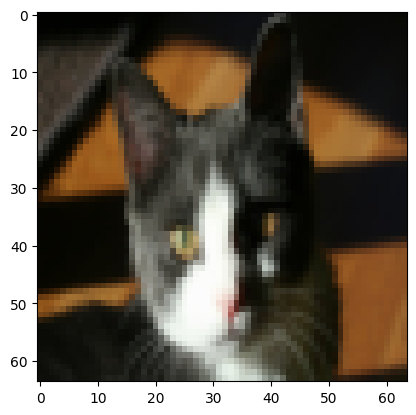

In [11]:
#---------------------- Load Data --------------------------
train_dataset = h5py.File('datasets/train_catvnoncat.h5', "r")
test_dataset = h5py.File('datasets/test_catvnoncat.h5', "r")

# get keys of dataset
# print(list(train_dataset.keys()))

# getting to know the shape of dataset by keys
# for key in train_dataset.keys():
#   data = train_dataset[key]
#   print(f"{key}: shape={data.shape}, dtype={data.dtype}")

train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])

test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y_orig = np.array(test_dataset["test_set_y"][:])

classes = np.array(train_dataset["list_classes"][:])

#---------------------- Reshape --------------------------

X_train = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
X_test = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

Y_test = test_set_y_orig.reshape(1, test_set_y_orig.shape[0])
Y_train = train_set_y_orig.reshape(1, train_set_y_orig.shape[0])


print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

#---------------------- Standardize --------------------------
X_train = X_train /255.0
X_test = X_test / 255.0

#---------------------- Visualize --------------------------
index = 19
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y_orig[index]) + ". It's a " + classes[train_set_y_orig[index]].decode("utf-8") +  " picture.")